In [1]:
!pip install numpy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np

import numpy as np

def carica_embedding_numpy_safe(file_path):
    word_to_idx = {}
    vectors = []
    expected_dim = None # La scopriremo leggendo la prima riga valida

    print("Inizio caricamento... potrebbe volerci un minuto.")

    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            parti = line.split()

            # 1. Salta righe troppo corte (come l'header o righe vuote)
            if len(parti) < 10:
                continue

            parola = parti[0]
            try:
                # Trasformiamo i numeri in una lista di float
                vettore_numeri = [float(x) for x in parti[1:]]

                # 2. Definiamo la dimensione attesa dal primo vettore "buono"
                if expected_dim is None:
                    expected_dim = len(vettore_numeri)
                    print(f"Dimensione rilevata: {expected_dim}")

                # 3. Solo se la dimensione è corretta aggiungiamo alla lista
                if len(vettore_numeri) == expected_dim:
                    word_to_idx[parola] = len(vectors)
                    vectors.append(vettore_numeri)
                # else: opzionale: print(f"Errore alla riga {i}: dimensione errata.")

            except ValueError:
                # Salta righe dove i valori non sono numeri
                continue

    print(f"Caricamento completato! Parole valide: {len(vectors)}")
    return word_to_idx, np.array(vectors)

# Utilizzo
word_to_idx, matrice = carica_embedding_numpy_safe("data/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt")

print(f"Parole caricate: {len(word_to_idx)}")
print(f"Dimensioni dei vettori: {matrice.shape[1]}")

idx_to_word = {i: w for w, i in word_to_idx.items()}

print(f"Matrice caricata: {matrice.shape}") # Es: (200000, 300)

Inizio caricamento... potrebbe volerci un minuto.
Dimensione rilevata: 50
Caricamento completato! Parole valide: 1287614
Parole caricate: 1287614
Dimensioni dei vettori: 50
Matrice caricata: (1287614, 50)


In [45]:
# Normalizziamo la matrice per velocizzare i calcoli futuri
norms = np.linalg.norm(matrice, axis=1, keepdims=True)
matrix_norm = matrice / norms

def get_similarity(w1, w2):
    v1 = matrix_norm[word_to_idx[w1]]
    v2 = matrix_norm[word_to_idx[w2]]
    return np.dot(v1, v2)

print(f"{get_similarity('pizza', 'pizzaiolo'):.4f}")

0.3093


In [48]:
def find_most_similar(vector, top_n=5):
    # Prodotto scalare tra il vettore e tutta la matrice normalizzata

    similarities = np.dot(matrix_norm, vector)

    # Prendi gli indici dei valori più alti
    best_indices = np.argsort(similarities)[-top_n:][::-1]

    return [(idx_to_word[i], similarities[i]) for i in best_indices]

print("Simili a 'computer':", find_most_similar(matrix_norm[word_to_idx['computer']]))

Simili a 'computer': [('computer', np.float64(0.9999999999999999)), ('computers', np.float64(0.9283039150954088)), ('software', np.float64(0.9077559902738432)), ('technology', np.float64(0.8772529103408017)), ('digital', np.float64(0.8438474147251029))]


In [76]:
def analogy(a, b, c):
    # Formula: b - a + c (es: uomo -> re, donna -> ?)
    va = matrix_norm[word_to_idx[a]]
    vb = matrix_norm[word_to_idx[b]]
    vc = matrix_norm[word_to_idx[c]]

    target_vector = vb - va + vc
    target_vector = target_vector / np.linalg.norm(target_vector)
    return find_most_similar(target_vector, top_n=3)

# Esempio: "parigi" sta a "francia" come "roma" sta a...
print("Analogia:", analogy('king', 'queen','uncle'))

Analogia: [('aunt', np.float64(0.8749482299375583)), ('daughter', np.float64(0.87058569153928)), ('granddaughter', np.float64(0.8595938025118127))]


In [68]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Definiamo dei gruppi semantici per vedere se la t-SNE li raggruppa
words_to_plot = [
    # Animals
    "dog", "cat", "horse", "wolf", "tiger", "lion",
    # Technology
    "computer", "software", "laptop", "internet", "website", "code",
    # Food
    "pizza", "burger", "bread", "fruit", "vegetable", "cheese",
    # Royalty
    "king", "queen", "prince", "princess", "empire", "throne",

]

# Estraiamo i vettori corrispondenti
indices = [word_to_idx[w] for w in words_to_plot if w in word_to_idx]
selected_vectors = matrix_norm[indices]
labels = [idx_to_word[i] for i in indices]

In [69]:
# Inizializziamo t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca', learning_rate='auto')

# Riduciamo la dimensionalità
# Da (n_words, 50) a (n_words, 2)
low_dim_vectors = tsne.fit_transform(selected_vectors)

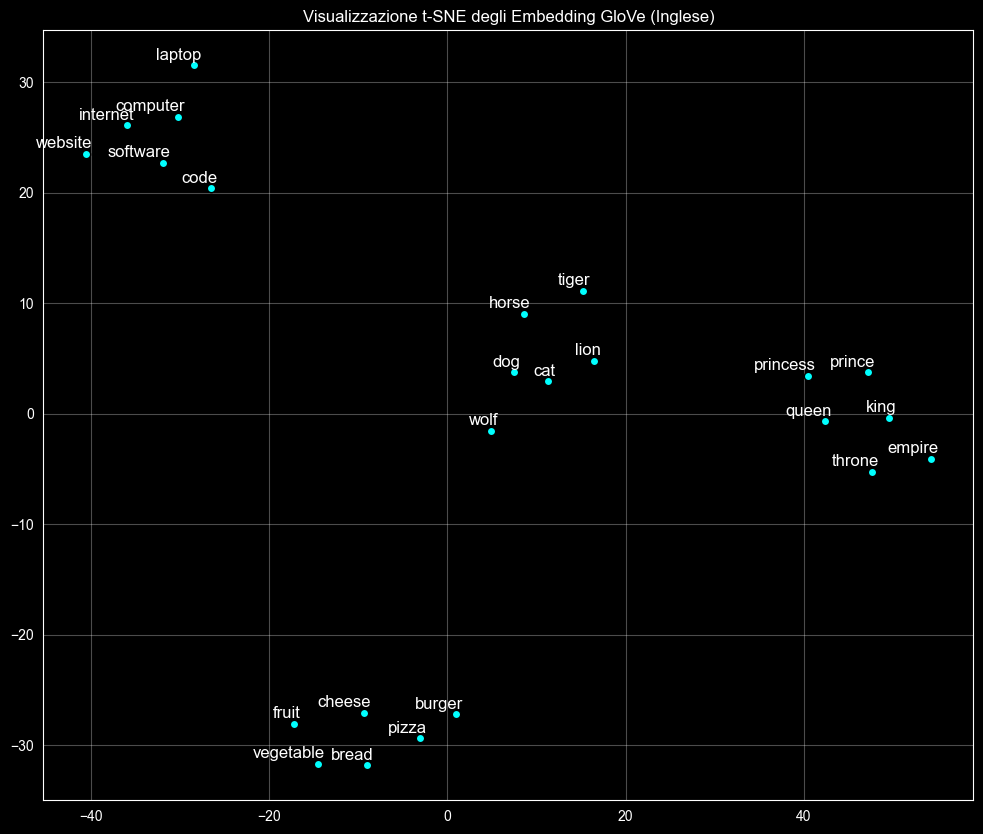

In [70]:
plt.figure(figsize=(12, 10))

# Disegniamo i punti
plt.scatter(low_dim_vectors[:, 0], low_dim_vectors[:, 1], edgecolors='k', c='cyan')

# Aggiungiamo le etichette
for i, label in enumerate(labels):
    plt.annotate(label,
                 xy=(low_dim_vectors[i, 0], low_dim_vectors[i, 1]),
                 xytext=(5, 2),
                 textcoords='offset points',
                 ha='right',
                 va='bottom',
                 fontsize=12)

plt.title("Visualizzazione t-SNE degli Embedding GloVe (Inglese)")
plt.grid(True, alpha=0.3)
plt.show()